# Chapter 7 — Mixture Models

Notes on Chapter 7 of *Bayesian Analysis with Python* (3rd edition).

## Set-up

### Imports

In [ ]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
import seaborn as sns

import const

### Defaults

In [2]:
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(const.RANDOM_SEED)

### Constants

In [3]:
# Data file paths and other hardcoded values go here

## Load data

In [4]:
cs = pd.read_csv(const.CHEMICAL_SHIFTS_DATA_PATH)
# cs_exp = cs['exp']

## Notes

### The Dirichlet distribution

The Dirichlet is the multivariate generalisation of the Beta.
Where the Beta puts a distribution over a single probability $p \in [0, 1]$, the Dirichlet puts a distribution over a probability vector $\mathbf{x} = (x_1, \dots, x_K)$ that lives on the *simplex*: $x_i \ge 0$ and $\sum_i x_i = 1$.
It is therefore the natural prior for the mixing weights of a $K$-component mixture, or for any set of category probabilities.

It has a concentration parameter $\boldsymbol{\alpha} = (\alpha_1, \dots, \alpha_K)$ with each $\alpha_i > 0$, playing the same role as the Beta's $(\alpha, \beta)$:

\begin{align*}
\mathbf{x} &\sim \text{Dir}(\boldsymbol{\alpha}) \\
p(\mathbf{x}) &\propto \prod_{i=1}^{K} x_i^{\alpha_i - 1}
\end{align*}

The Beta is exactly the $K = 2$ case: $\text{Beta}(\alpha, \beta) = \text{Dir}(\alpha, \beta)$ once you identify $p$ with $(p, 1-p)$.

**Interpreting $\boldsymbol{\alpha}$:**

- The mean is $\mathbb{E}[x_i] = \alpha_i / \sum_j \alpha_j$ — the $\alpha_i$ act like relative "pseudo-counts", so their proportions set where the distribution is centred.
- Their *sum* $\alpha_0 = \sum_j \alpha_j$ controls concentration: large $\alpha_0$ concentrates mass tightly around the mean, small $\alpha_0$ spreads it toward the corners of the simplex.
- A symmetric $\boldsymbol{\alpha} = (\alpha, \dots, \alpha)$ is uniform over categories; $\alpha = 1$ is uniform over the whole simplex, $\alpha < 1$ favours sparse vectors (mass on a few components), $\alpha > 1$ favours balanced vectors.

**Conjugacy:** the Dirichlet is conjugate to the categorical/multinomial, mirroring Beta–Binomial.
Observing counts $\mathbf{n} = (n_1, \dots, n_K)$ updates the posterior to $\text{Dir}(\boldsymbol{\alpha} + \mathbf{n})$ — just add the observed counts to the prior pseudo-counts.
This is why it is the default prior for mixture weights in the models below.

### Chemical mixture

Visualise the data

[Text(0.5, 1.0, 'Distribution of experimental chemical shifts'),
 Text(0.5, 0, 'Experimental chemical shift (ppm)')]

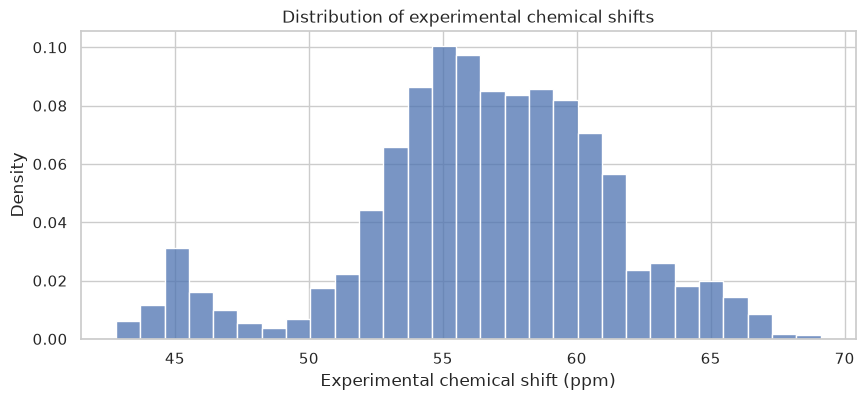

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(cs["exp"], stat="density", ax=ax)
ax.set(title="Distribution of experimental chemical shifts", xlabel="Experimental chemical shift (ppm)")

First the model that samples badly:

In [6]:
K = 2
coords = {"component": range(K), "obs": range(len(cs["exp"]))}
with pm.Model(coords=coords) as model_kg:
    # data
    cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
    cs_exp_mean = cs_exp.mean()

    # priors
    p = pm.Dirichlet('p', a=np.ones(K), dims="component")
    z = pm.Categorical('z', p=p, dims="obs")
    means = pm.Normal('means', mu=cs_exp_mean, sigma=10, dims="component")
    sd = pm.Exponential('sd', scale=5)

    # likelihood
    y = pm.Normal('y', mu=means[z], sigma=sd, observed=cs_exp, dims="obs")

    # sample
    idata_kg = pm.sample(draws=500, chains=4, random_seed=const.RANDOM_SEED)

Multiprocess sampling (4 chains in 2 jobs)
CompoundStep
>NUTS: [p, means, sd]
>BinaryGibbsMetropolis: [z]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 121 seconds.
/home/coder/bayesian-analysis-with-python/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:90: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


In [7]:
model_kg

Summary shows terrible `r_hat` and ESS (effective sample size)

In [8]:
pm.summary(idata_kg, var_names=["~z"], ci_prob=0.94, round_to=2)

/tmp/ipykernel_8646/251366504.py:1: DeprecationWarning: `pymc.summary` was moved out of the root namespace and will be removed in the first PyMC release of 2027. Use `pymc.stats.summary` instead.
  pm.summary(idata_kg, var_names=["~z"], ci_prob=0.94, round_to=2)


,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
means[0],57.46,0.10,57.29,57.65,1243.74,1265.81,1.00,0.00,0.00
means[1],46.82,0.42,46.01,47.60,652.49,921.29,1.01,0.02,0.01
p[0],0.91,0.01,0.89,0.92,842.26,1006.42,1.01,0.00,0.00
p[1],0.09,0.01,0.08,0.11,842.26,1006.42,1.01,0.00,0.00
sd,3.65,0.07,3.52,3.79,1352.52,1398.57,1.00,0.00,0.00


Trace plot confirms that the chains aren't mixing.

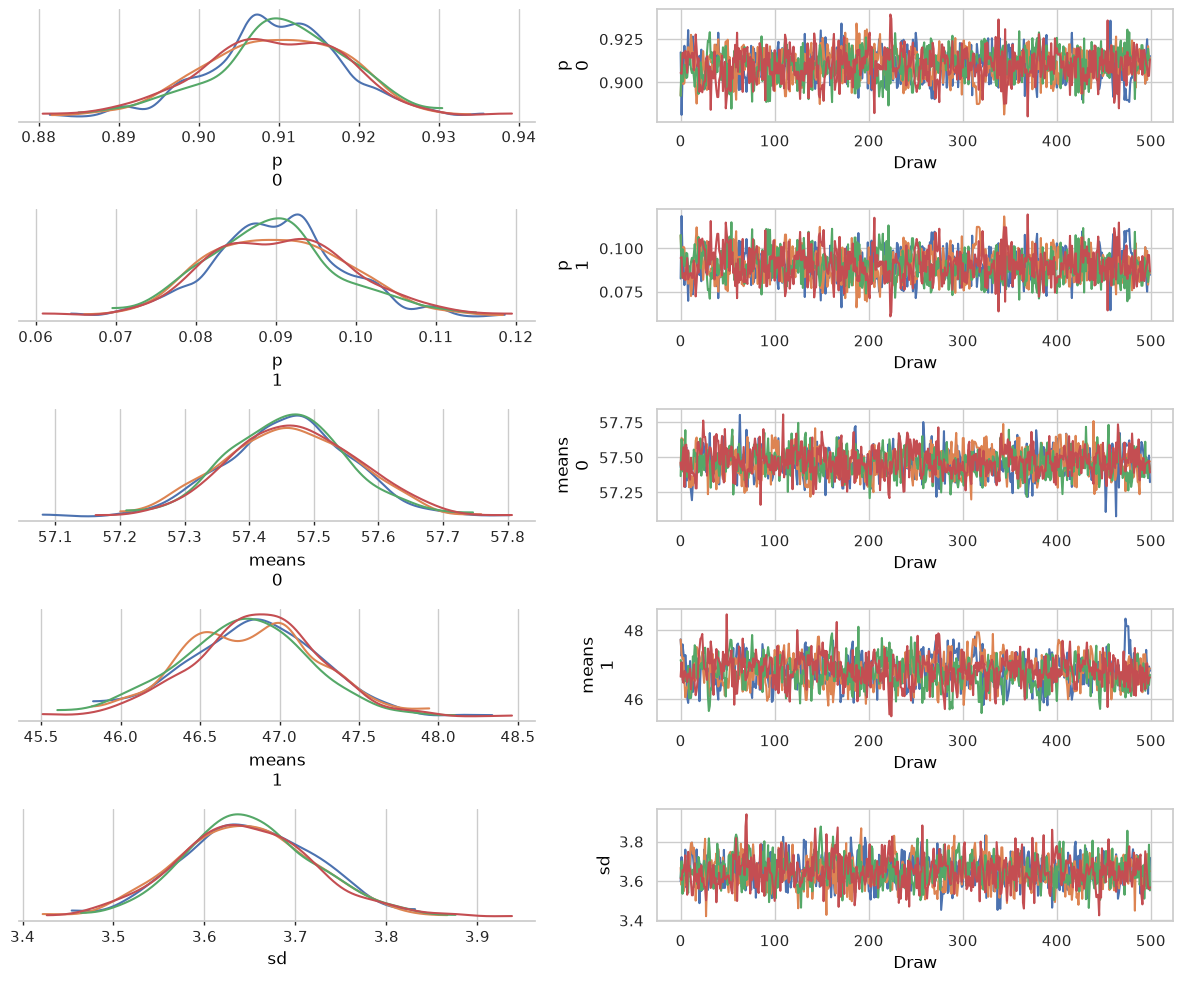

In [9]:
pc = az.plot_trace_dist(
    idata_kg,
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 10)
fig.tight_layout()

We can improve the sampling with marginalisation.
Luckily PyMC can handle that with `NormalMixture`

In [10]:
K = 2
coords = {"component": range(K), "obs": range(len(cs["exp"]))}
with pm.Model(coords=coords) as model_mg:
    # data
    cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
    cs_exp_mean = cs_exp.mean()

    # priors
    p = pm.Dirichlet('p', a=np.ones(K), dims="component")
    means = pm.Normal('means', mu=cs_exp_mean, sigma=10, dims="component")
    sd = pm.Exponential('sd', scale=5)

    # likelihood
    y = pm.NormalMixture('y', w=p, mu=means, sigma=sd, observed=cs_exp, dims="obs")

    # sample
    idata_mg = pm.sample(draws=1000, chains=4, random_seed=const.RANDOM_SEED)

NUTS[nutpie]: [p, means, sd]


Output()

This runs a lot faster but the r_hat is still high

In [11]:
pm.summary(idata_mg, ci_prob=0.94, round_to=2)

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
means[0],54.82,4.60,46.36,57.64,7.23,10.78,1.53,2.29,1.33
means[1],49.49,4.62,46.07,57.58,7.17,10.66,1.53,2.29,1.32
p[0],0.71,0.35,0.08,0.92,7.20,11.04,1.53,0.18,0.10
p[1],0.29,0.35,0.08,0.92,7.20,11.04,1.53,0.18,0.10
sd,3.65,0.07,3.52,3.79,4851.68,3441.72,1.00,0.00,0.00


The chains still aren't mixing.

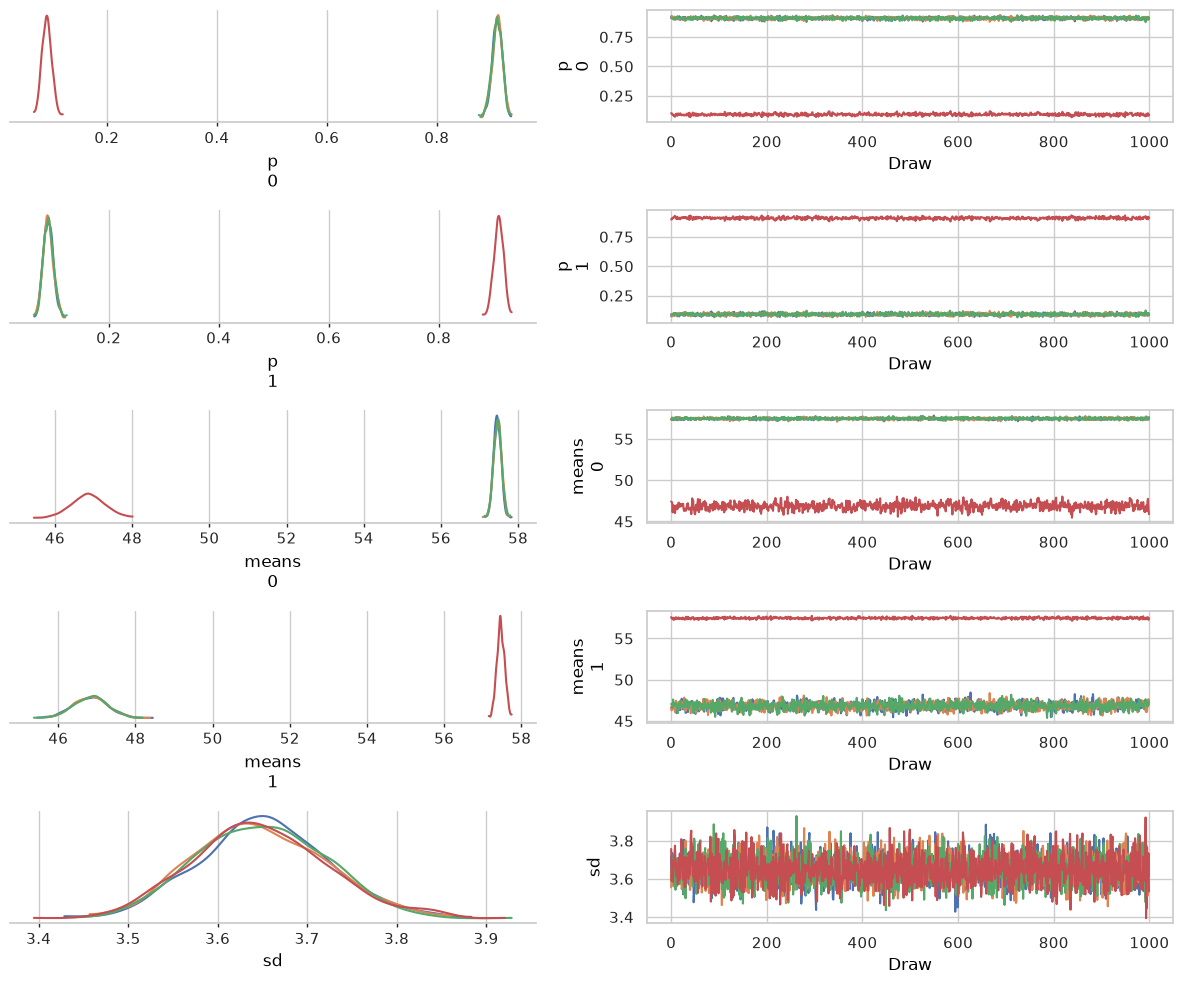

In [12]:
pc = az.plot_trace_dist(
    idata_mg,
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 10)
fig.tight_layout()

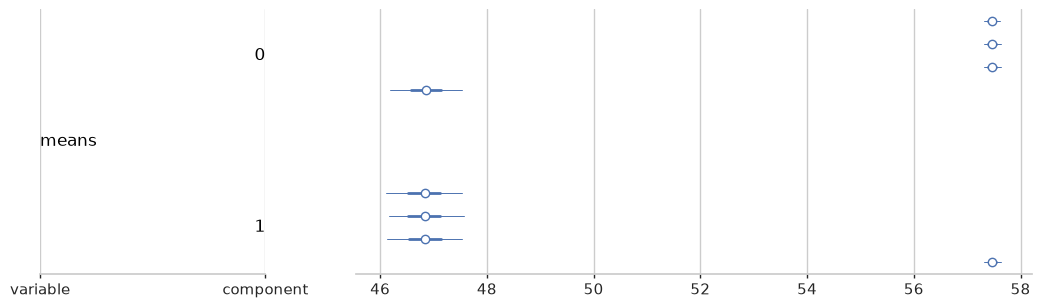

In [13]:
az.plot_forest(
    idata_mg,
    var_names=["means"]
);

This is because of non-identifiability in the model

### The non-identifiability of mixture models

We resolve the non-identifiability issue by forcing them to be ordered

In [14]:
K = 2
coords = {"component": range(K), "obs": range(len(cs["exp"]))}
with pm.Model(coords=coords) as model_mgo:
    # data
    cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
    cs_exp_mean = cs_exp.mean()

    # priors
    p = pm.Dirichlet('p', a=np.ones(K), dims="component")
    means = pm.Normal('means', mu=cs_exp_mean, sigma=10, dims="component",
                      transform=pm.distributions.transforms.ordered,
                      initval=np.array([cs["exp"].mean()-1, cs["exp"].mean()+1]))
    sd = pm.Exponential('sd', lam=5)

    # likelihood
    y = pm.NormalMixture('y', w=p, mu=means, sigma=sd, observed=cs_exp, dims="obs")

    # sample
    idata_mgo = pm.sample(draws=1000, chains=4, random_seed=const.RANDOM_SEED)

NUTS[nutpie]: [p, means, sd]


Output()

Now it's all good

In [15]:
pm.summary(idata_mgo, ci_prob=0.94, round_to=2)

,mean,sd,eti94_lb,eti94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p[0],0.09,0.01,0.07,0.11,2005.82,2206.97,1.00,0.00,0.00
p[1],0.91,0.01,0.89,0.93,2005.82,2206.97,1.00,0.00,0.00
means[0],46.85,0.42,46.08,47.65,807.45,837.64,1.01,0.02,0.01
means[1],57.47,0.10,57.28,57.65,4337.17,2919.50,1.00,0.00,0.00
sd,3.63,0.07,3.50,3.77,2702.14,2335.79,1.00,0.00,0.00


Chains are mixing

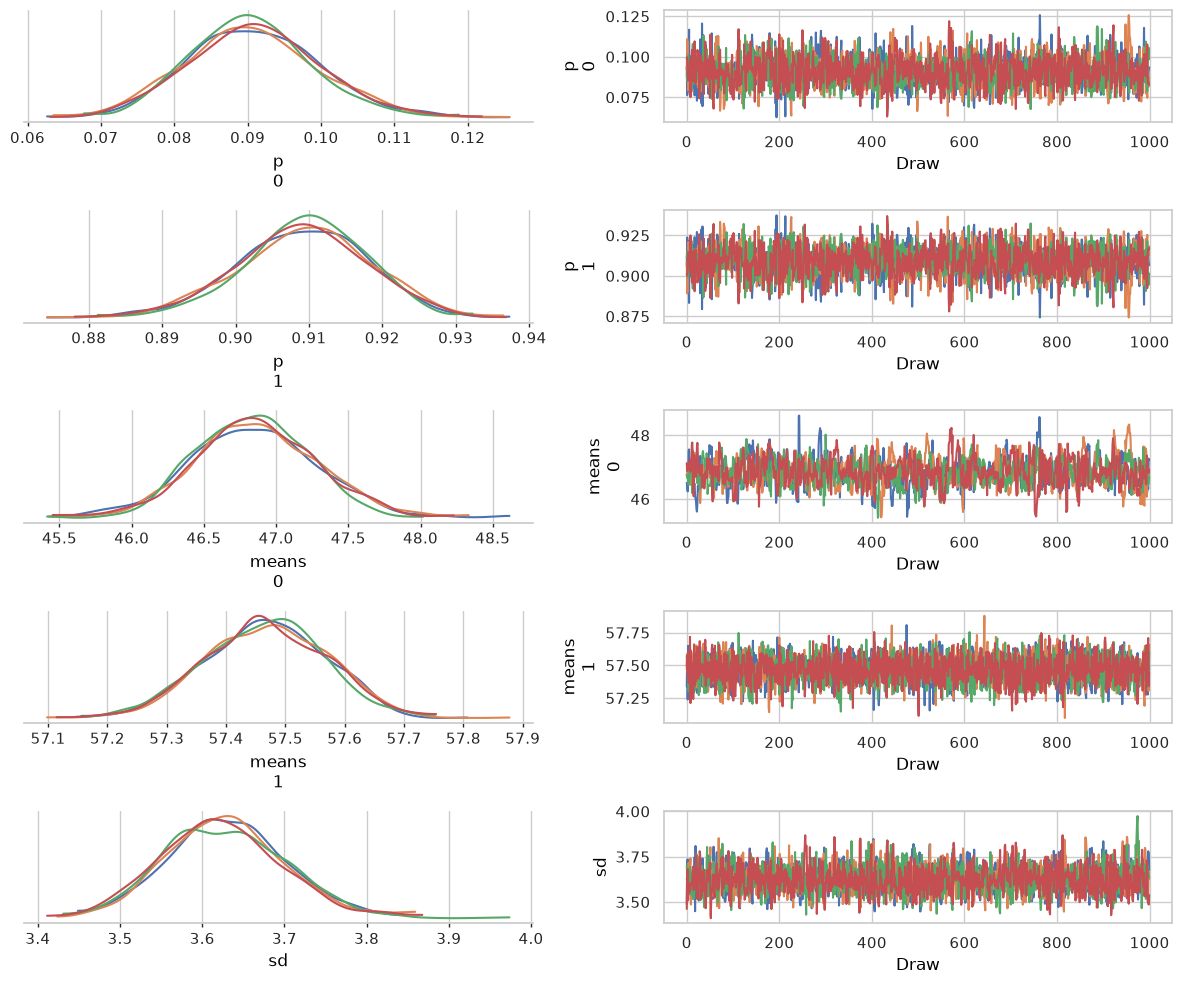

In [16]:
pc = az.plot_trace_dist(
    idata_mgo,
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 10)
fig.tight_layout()

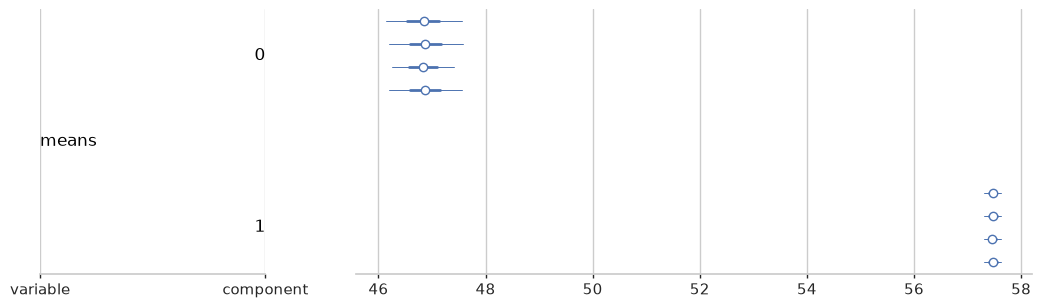

In [17]:
az.plot_forest(
    idata_mgo,
    var_names=["means"]
);

### How to choose K

Try different values of K.

In [22]:
Ks = [2, 3, 4, 5]
models = {}
idatas = {}
for K in Ks:
    coords = {"component": range(K), "obs": range(len(cs["exp"]))}
    with pm.Model(coords=coords) as model:
        # data
        cs_exp = pm.Data("cs_exp", cs["exp"], dims="obs")
        cs_exp_mean = cs_exp.mean()

        # priors
        p = pm.Dirichlet("p", a=np.ones(K), dims="component")
        means = pm.Normal(
            "means", mu=cs_exp_mean, sigma=10, dims="component",
            transform=pm.distributions.transforms.ordered,
            initval=cs["exp"].mean() + np.linspace(-1, 1, K),
        )
        sd = pm.Exponential("sd", lam=5)

        # likelihood
        y = pm.NormalMixture("y", w=p, mu=means, sigma=sd, observed=cs_exp, dims="obs")

        # sample
        idata = pm.sample(draws=1000, chains=4, target_accept=0.95, random_seed=const.RANDOM_SEED)

    idatas[K] = idata
    models[K] = model

NUTS[nutpie]: [p, means, sd]


Output()

NUTS[nutpie]: [p, means, sd]


Output()

NUTS[nutpie]: [p, means, sd]


Output()

NUTS[nutpie]: [p, means, sd]


Output()

Quick convergence checks

In [23]:
for K, idata in idatas.items():
    summ = pm.summary(idata, var_names=["p", "means", "sd"], ci_prob=0.94, round_to=2)
    print(f"K={K}: max r_hat={summ['r_hat'].max():.2f}, min ess_bulk={summ['ess_bulk'].min():.0f}")

K=2: max r_hat=1.00, min ess_bulk=689
K=3: max r_hat=1.00, min ess_bulk=1232
K=4: max r_hat=1.00, min ess_bulk=1476
K=5: max r_hat=1.01, min ess_bulk=845


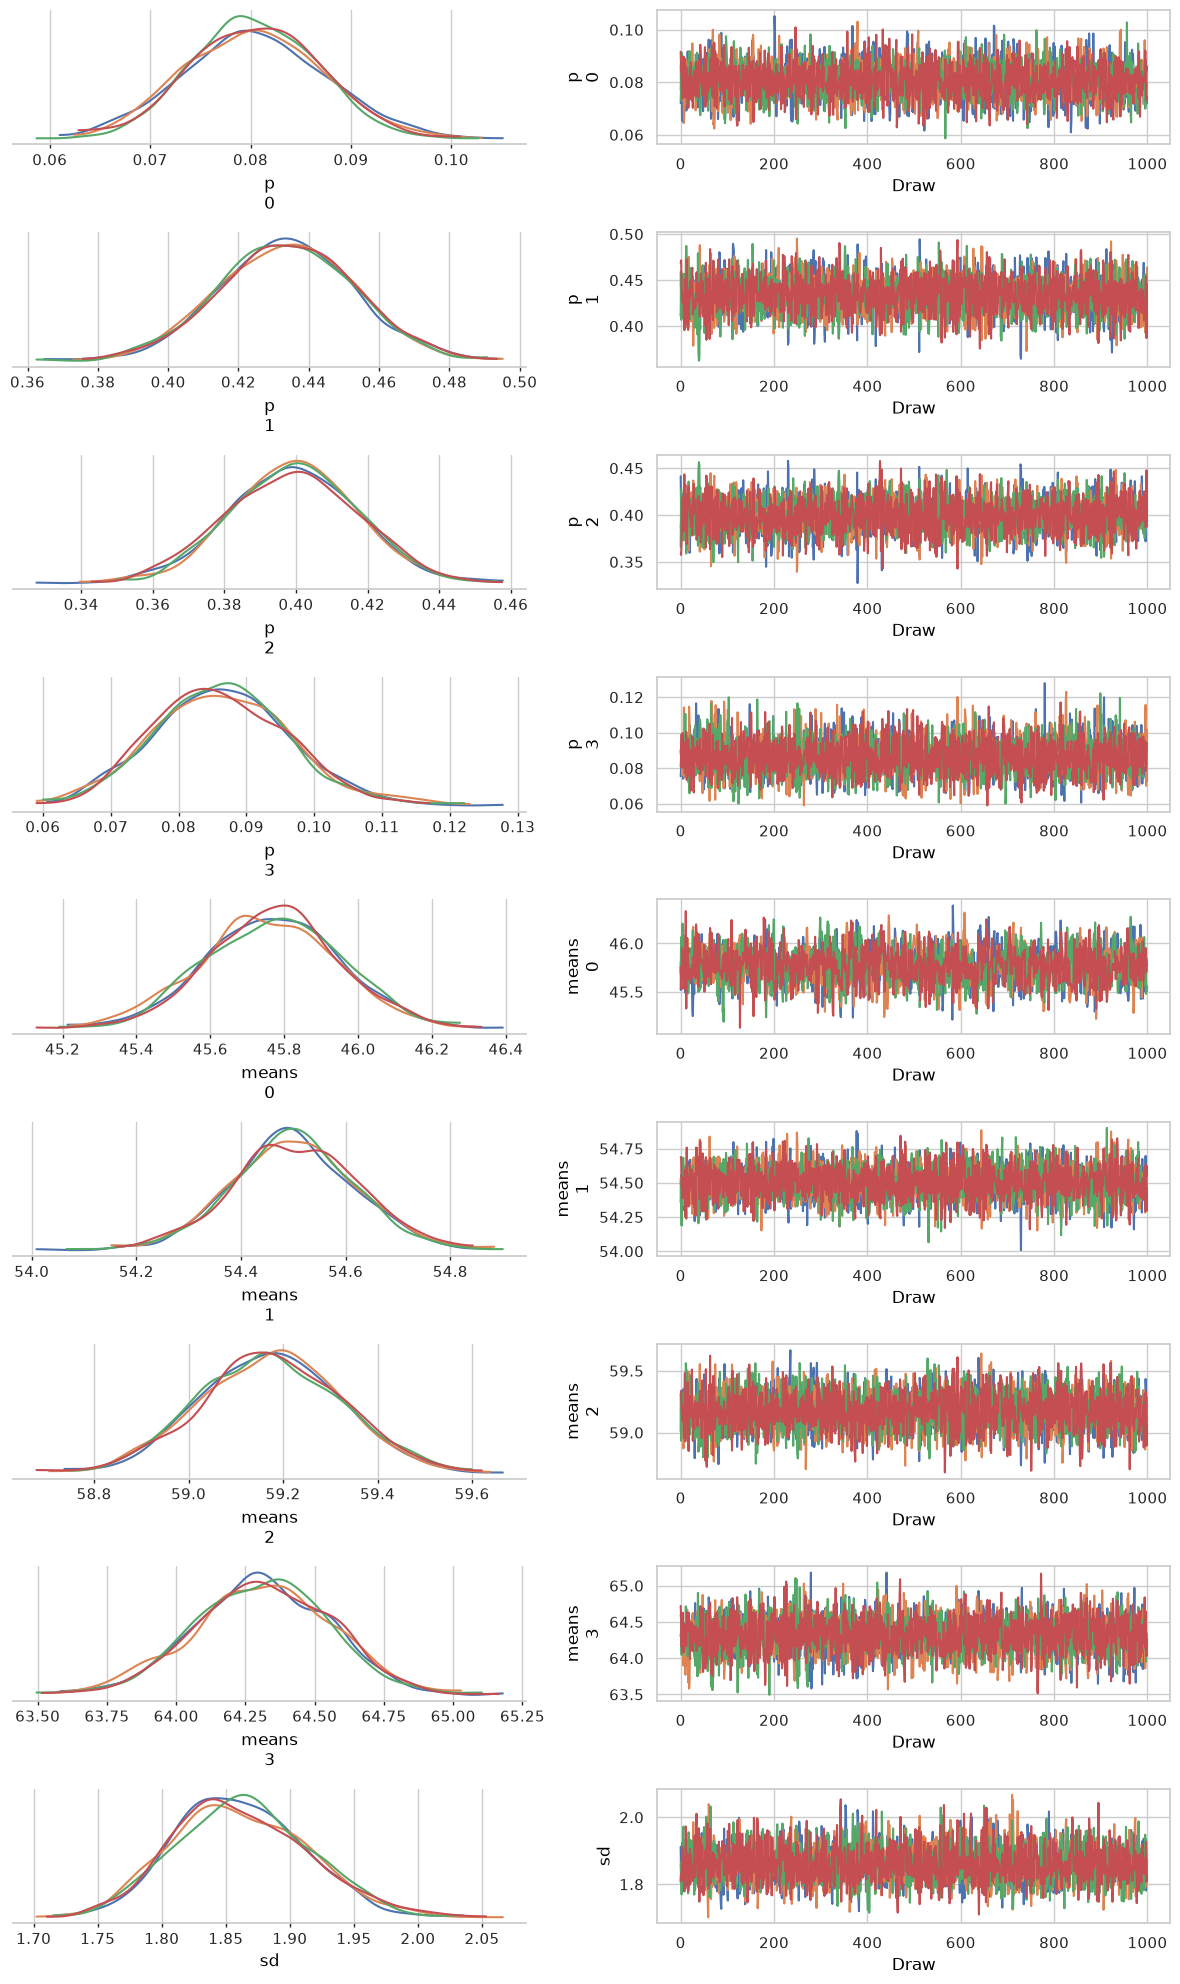

In [24]:
pc = az.plot_trace_dist(
    idatas[4],
    var_names=["p", "means", "sd"],
    compact=False,
    combined=False
)
fig = pc.viz["figure"].item()
fig.set_size_inches(12, 20)
fig.tight_layout()

Plot the posterior means

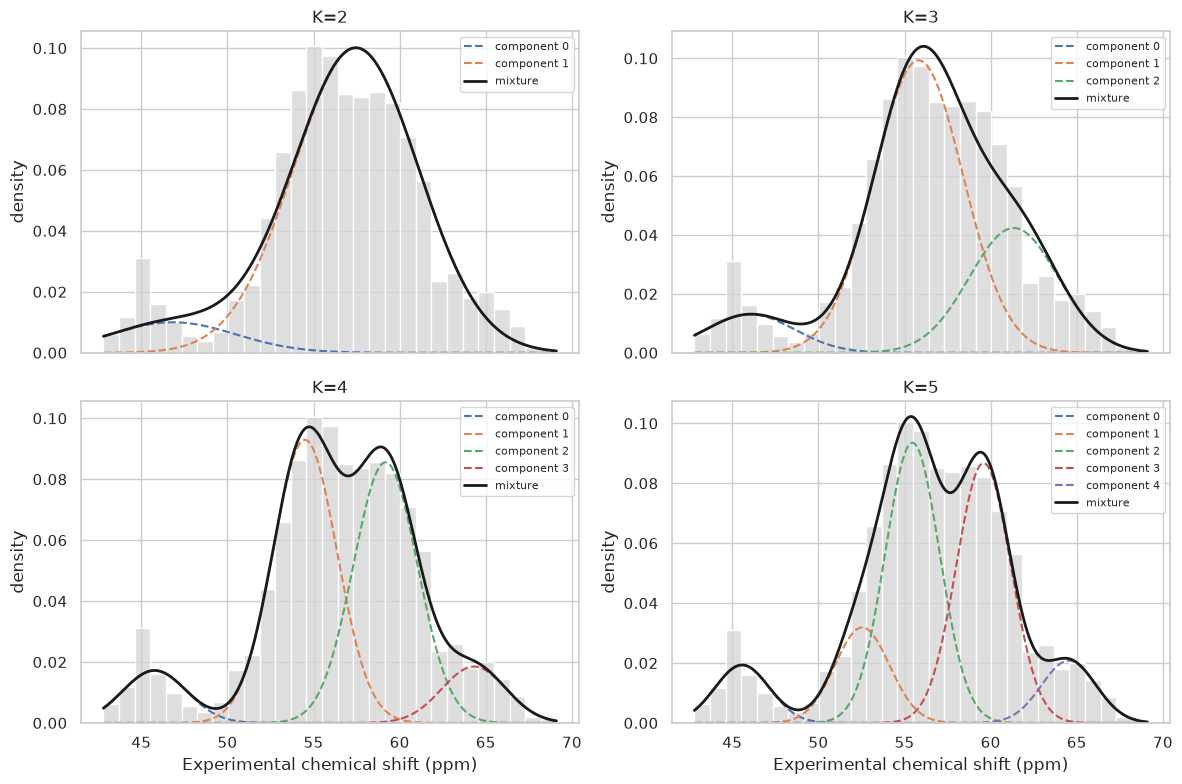

In [ ]:
x = np.linspace(cs["exp"].min(), cs["exp"].max(), 500)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (K, idata) in zip(axes.flat, idatas.items()):
    post = idata.posterior
    p = post["p"].mean(("chain", "draw")).values
    means = post["means"].mean(("chain", "draw")).values
    sd = post["sd"].mean(("chain", "draw")).item()

    sns.histplot(cs["exp"], stat="density", ax=ax, color="lightgray", edgecolor="white")

    total = np.zeros_like(x)
    for k in range(K):
        comp = p[k] * stats.norm.pdf(x, means[k], sd)
        total += comp
        ax.plot(x, comp, "--", lw=1.5, label=f"component {k}")
    ax.plot(x, total, "k-", lw=2, label="mixture")
    ax.set(title=f"K={K}", ylabel="density")
    ax.legend(fontsize=8)

axes[1, 0].set_xlabel("Experimental chemical shift (ppm)")
axes[1, 1].set_xlabel("Experimental chemical shift (ppm)")
fig.tight_layout()